In [1]:
#importing required libraries
!pip install pandas numpy scikit-learn nltk matplotlib seaborn wordcloud

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline

nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [3]:
#loading the dataset

!wget https://raw.githubusercontent.com/mohitgupta-1O1/Kaggle-SMS-Spam-Collection-Dataset-/master/spam.csv -O spam.csv

# Load the data
df = pd.read_csv('spam.csv', encoding='latin-1')
df = df.iloc[:, :2]  # Keep only first two columns (label and message)
df.columns = ['label', 'message']

# Map labels: ham=0 (genuine), spam=1 (scam)
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

print(df.head())
print(df['label'].value_counts())

--2026-06-08 06:42:09--  https://raw.githubusercontent.com/mohitgupta-1O1/Kaggle-SMS-Spam-Collection-Dataset-/master/spam.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 503663 (492K) [application/octet-stream]
Saving to: ‘spam.csv’

spam.csv            100%[===================>] 491.86K  --.-KB/s    in 0.1s    

2026-06-08 06:42:09 (4.11 MB/s) - ‘spam.csv’ saved [503663/503663]

   label                                            message
0      0  Go until jurong point, crazy.. Available only ...
1      0                      Ok lar... Joking wif u oni...
2      1  Free entry in 2 a wkly comp to win FA Cup fina...
3      0  U dun say so early hor... U c already then say...
4      0  Nah I don't think he goes to usf, he lives aro...
label
0    4825
1    

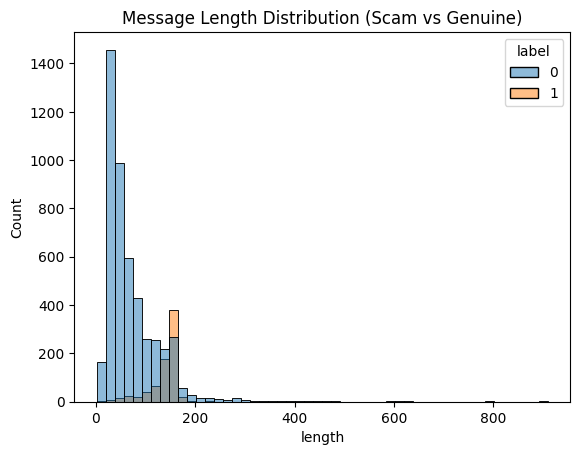

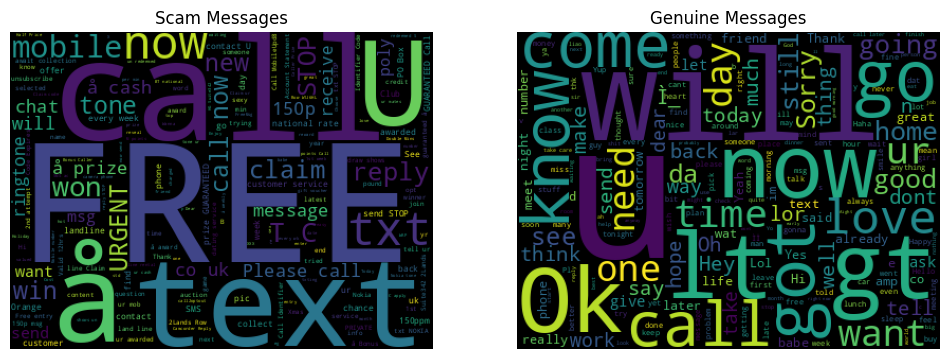

In [4]:
#EDA

# Message length
df['length'] = df['message'].apply(len)
sns.histplot(data=df, x='length', hue='label', bins=50)
plt.title('Message Length Distribution (Scam vs Genuine)')
plt.show()

# Word clouds (install wordcloud if needed)
from wordcloud import WordCloud

spam_text = ' '.join(df[df['label']==1]['message'])
ham_text = ' '.join(df[df['label']==0]['message'])

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(WordCloud(width=400, height=300).generate(spam_text))
plt.title('Scam Messages')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(WordCloud(width=400, height=300).generate(ham_text))
plt.title('Genuine Messages')
plt.axis('off')
plt.show()

In [5]:
# preprocessing the text
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = re.sub('[^a-zA-Z]', ' ', text)  # Remove non-letters
    text = text.lower().split()
    text = [stemmer.stem(word) for word in text if word not in stop_words]
    return ' '.join(text)

df['cleaned_message'] = df['message'].apply(preprocess_text)
print(df[['message', 'cleaned_message']].head())

                                             message  \
0  Go until jurong point, crazy.. Available only ...   
1                      Ok lar... Joking wif u oni...   
2  Free entry in 2 a wkly comp to win FA Cup fina...   
3  U dun say so early hor... U c already then say...   
4  Nah I don't think he goes to usf, he lives aro...   

                                     cleaned_message  
0  go jurong point crazi avail bugi n great world...  
1                              ok lar joke wif u oni  
2  free entri wkli comp win fa cup final tkt st m...  
3                u dun say earli hor u c alreadi say  
4               nah think goe usf live around though  


In [6]:
#training

X = df['cleaned_message']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create pipeline
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000)),
    ('classifier', MultinomialNB())
])

pipeline.fit(X_train, y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer(max_features=5000)),
                ('classifier', MultinomialNB())])

In [7]:
y_pred = pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9659192825112107

Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       1.00      0.75      0.85       150

    accuracy                           0.97      1115
   macro avg       0.98      0.87      0.92      1115
weighted avg       0.97      0.97      0.96      1115


Confusion Matrix:
 [[965   0]
 [ 38 112]]


In [8]:
def predict_scam(message):
    cleaned = preprocess_text(message)
    pred = pipeline.predict([cleaned])[0]
    prob = pipeline.predict_proba([cleaned])[0]
    result = "🚨 **SCAM / Fraudulent**" if pred == 1 else "✅ **Genuine**"
    print(result)
    print(f"Confidence - Scam: {prob[1]:.2%}, Genuine: {prob[0]:.2%}")

# Examples
predict_scam("Congratulations! You've won a $1000 prize. Click here to claim.")
predict_scam("Hey, are we still meeting for coffee tomorrow?")
predict_scam("Your bank account is suspended. Verify now: [fake link]")

🚨 **SCAM / Fraudulent**
Confidence - Scam: 92.28%, Genuine: 7.72%
✅ **Genuine**
Confidence - Scam: 0.41%, Genuine: 99.59%
✅ **Genuine**
Confidence - Scam: 29.37%, Genuine: 70.63%


In [9]:
import joblib
joblib.dump(pipeline, 'scam_detector_model1.pkl')

from google.colab import files
files.download('scam_detector_model1.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>